<a href="https://colab.research.google.com/github/megadeazzahra/Clustering/blob/main/Clustering_Country.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clustering Country**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
import kagglehub
rohan0301_unsupervised_learning_on_country_data_path = kagglehub.dataset_download('rohan0301/unsupervised-learning-on-country-data')

print('Data source import complete.')


Data source import complete.


## 2. Load data

In [3]:
df_country = pd.read_csv("/kaggle/input/unsupervised-learning-on-country-data/Country-data.csv")
df_country.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df_country.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## 3. Exploratory Data Analysis

## 3.1 Data quality

### I | Check duplicates

In [6]:
duplicates = df_country.duplicated().sum()
print(duplicates)

0


tidak ada data yang duplikat sehingga dapat dilanjutkan

### II | Check null and missing values

In [7]:
missing_values = df_country.isnull().sum()
total_missing_values = (missing_values).sum()
total_cells = math.prod(df_country.shape)
percent_missing_values = (total_missing_values / total_cells)*100
print("Percent of data that is missing", percent_missing_values)
print(missing_values)

Percent of data that is missing 0.0
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


tidak ada data nilai yang  hilang

### III | Check unique values in each columns

In [8]:
for column in df_country.columns:
    num_distinct_values = len(df_country[column].unique())
    print(f"{column}: {num_distinct_values} distinct values")

country: 167 distinct values
child_mort: 139 distinct values
exports: 147 distinct values
health: 147 distinct values
imports: 151 distinct values
income: 156 distinct values
inflation: 156 distinct values
life_expec: 127 distinct values
total_fer: 138 distinct values
gdpp: 157 distinct values


### IV | Correlation Analysis

In [9]:
numeric_columns = df_country.select_dtypes(include=[np.number])
correlation_matrix = numeric_columns.corr()
correlation_matrix

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


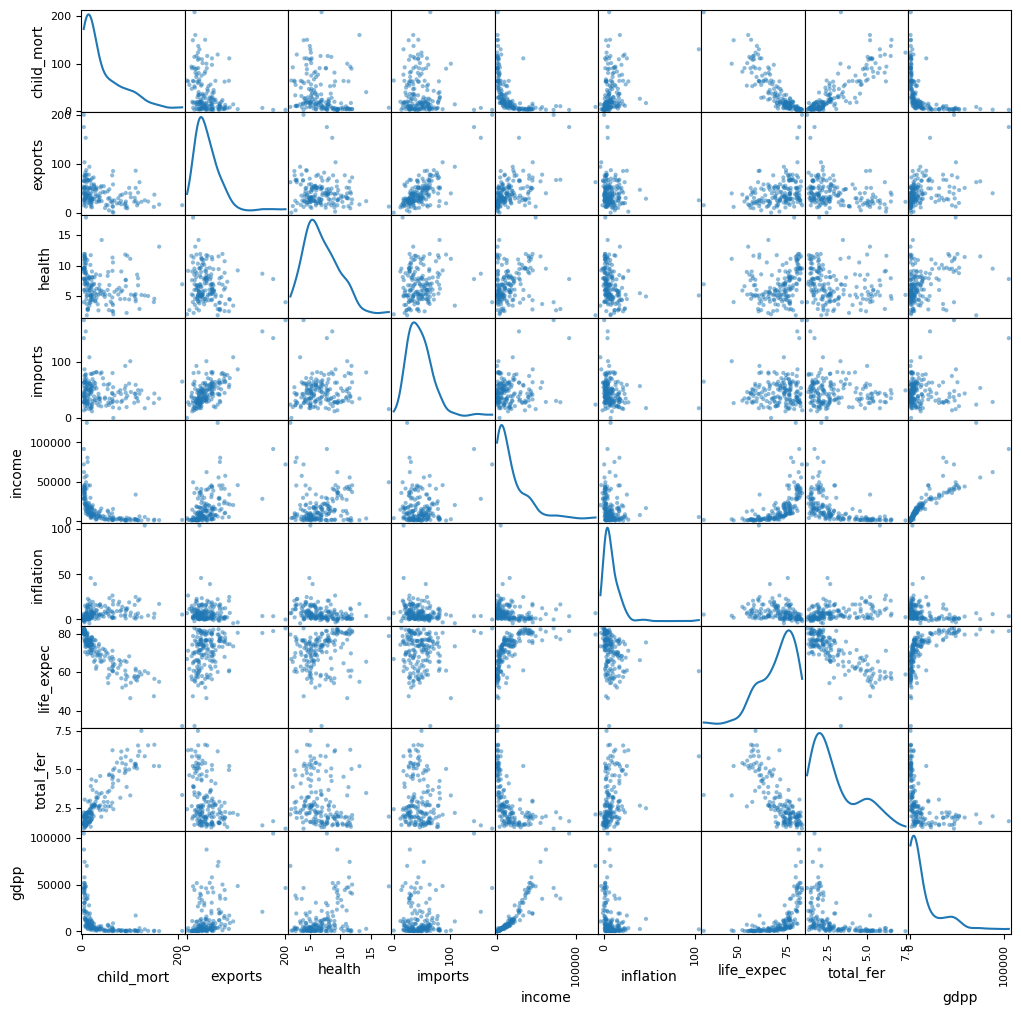

In [34]:
from pandas.plotting import scatter_matrix

scatter_matrix(df_country[numeric_columns.columns], alpha=0.5, figsize=(12, 12), diagonal='kde')
plt.show()

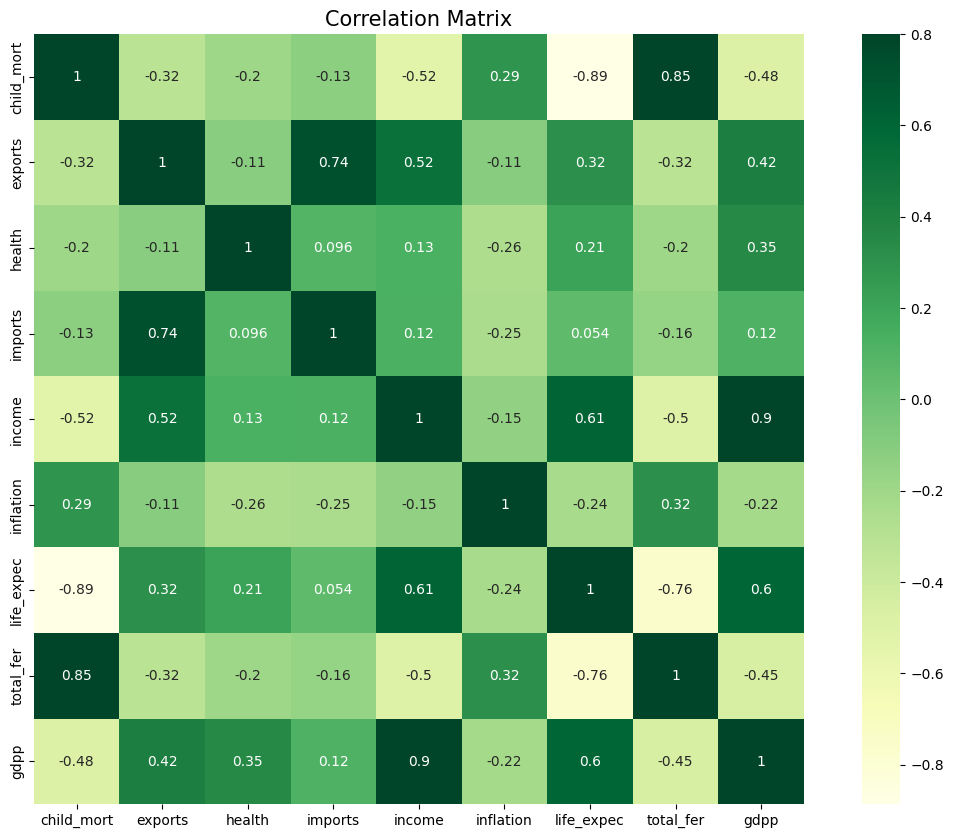

In [10]:
fig, ax = plt.subplots()
fig.set_size_inches(15,10)
sns.heatmap(correlation_matrix, vmax =.8, square = True, annot = True,cmap='YlGn' )
plt.title('Correlation Matrix',fontsize=15);

* income dan gdpp (0.9): Memiliki korelasi positif sangat kuat. Artinya, negara dengan pendapatan tinggi cenderung memiliki GDP per kapita yang tinggi pula.

* total_fer dan child_mort (0.85): Korelasi positif kuat menunjukkan bahwa negara dengan tingkat kesuburan total tinggi cenderung memiliki angka kematian anak yang tinggi.

* child_mort dan life_expec (-0.89): Korelasi negatif sangat kuat, menunjukkan bahwa negara dengan angka kematian anak yang tinggi cenderung memiliki harapan hidup yang rendah.

* Ada beberapa korelasi sedang (0.5 - 0.7) antara variabel lain, seperti exports dengan income dan gdpp, imports dengan income dan gdpp, dan health dengan life_expec.

* Variabel lainnya memiliki korelasi yang relatif lemah (di bawah 0.5).

Variabel dengan korelasi tinggi dan skala yang besar dapat mendominasi proses clustering, sehingga fitur lain menjadi kurang berpengaruh. PCA dapat digunakan untuk mereduksi dimensi data dan menghilangkan korelasi antar variabel.

### V | Normalization

In [11]:
col = list(df_country.columns)
col.remove('country')
categorical_features = ['country']
numerical_features = [*col]

memisahkan data categorical (country) dengan data numerical

In [12]:
scaler = MinMaxScaler().fit_transform(df_country[numerical_features])
df_scale = pd.DataFrame(scaler, columns=df_country[numerical_features].columns)

Penskalaan fitur membantu menyamakan kedudukan dengan membawa semua fitur ke skala yang serupa.

### VI | PCA

In [13]:
pca = PCA(n_components=9).fit(df_scale)
exp = pca.explained_variance_ratio_
print(exp)

[0.55001227 0.13384784 0.12301053 0.09749047 0.03777964 0.03013659
 0.01190434 0.00887791 0.00694042]


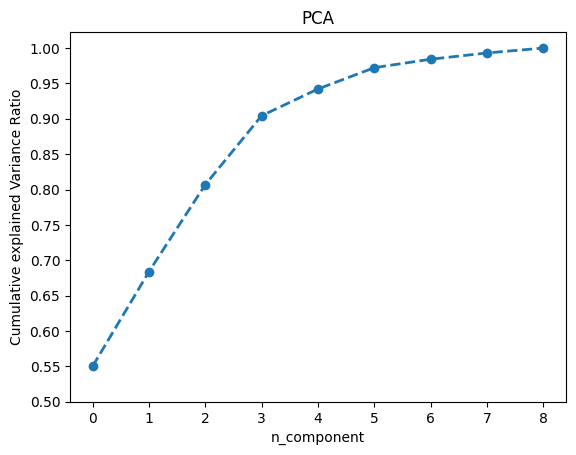

In [14]:
plt.plot(np.cumsum(exp), linewidth=2, marker = 'o', linestyle = '--')
plt.title("PCA")
plt.xlabel('n_component')
plt.ylabel('Cumulative explained Variance Ratio')
plt.yticks(np.arange(0.5, 1.05, 0.05))
plt.show()

kita cukup mengambil 5 komponen utamanya saja karena 5 komponen pertama sudah menjelaskan sekitar 95% variansi data, yang berarti sebagian besar informasi dalam data sudah tercakup.



In [15]:
finla_pca = IncrementalPCA(n_components=5).fit_transform(df_scale)
pc = np.transpose(finla_pca)

In [16]:
df = pd.DataFrame({
    'PC1':pc[0],
    'PC2':pc[1],
    'PC3':pc[2],
    'PC4':pc[3],
    'PC5':pc[4],
})
df

,PC1,PC2,PC3,PC4,PC5
0,0.599065,0.095506,0.157437,0.024382,0.042560
1,-0.158455,-0.212345,-0.063709,0.061067,-0.017134
2,-0.003661,-0.135842,-0.133938,-0.133376,0.092225
3,0.650272,0.276016,-0.143024,-0.155593,0.083921
4,-0.200684,-0.065162,-0.100418,0.037680,0.030574
...,...,...,...,...,...
162,0.160056,-0.030100,-0.121936,0.065807,0.007747
163,-0.061196,-0.169616,-0.058942,-0.245296,0.112279
164,-0.115510,-0.032083,-0.195224,0.232604,0.040592
165,0.332967,-0.019417,-0.030055,-0.104661,0.145588


## 3.2 Univariative Analysis

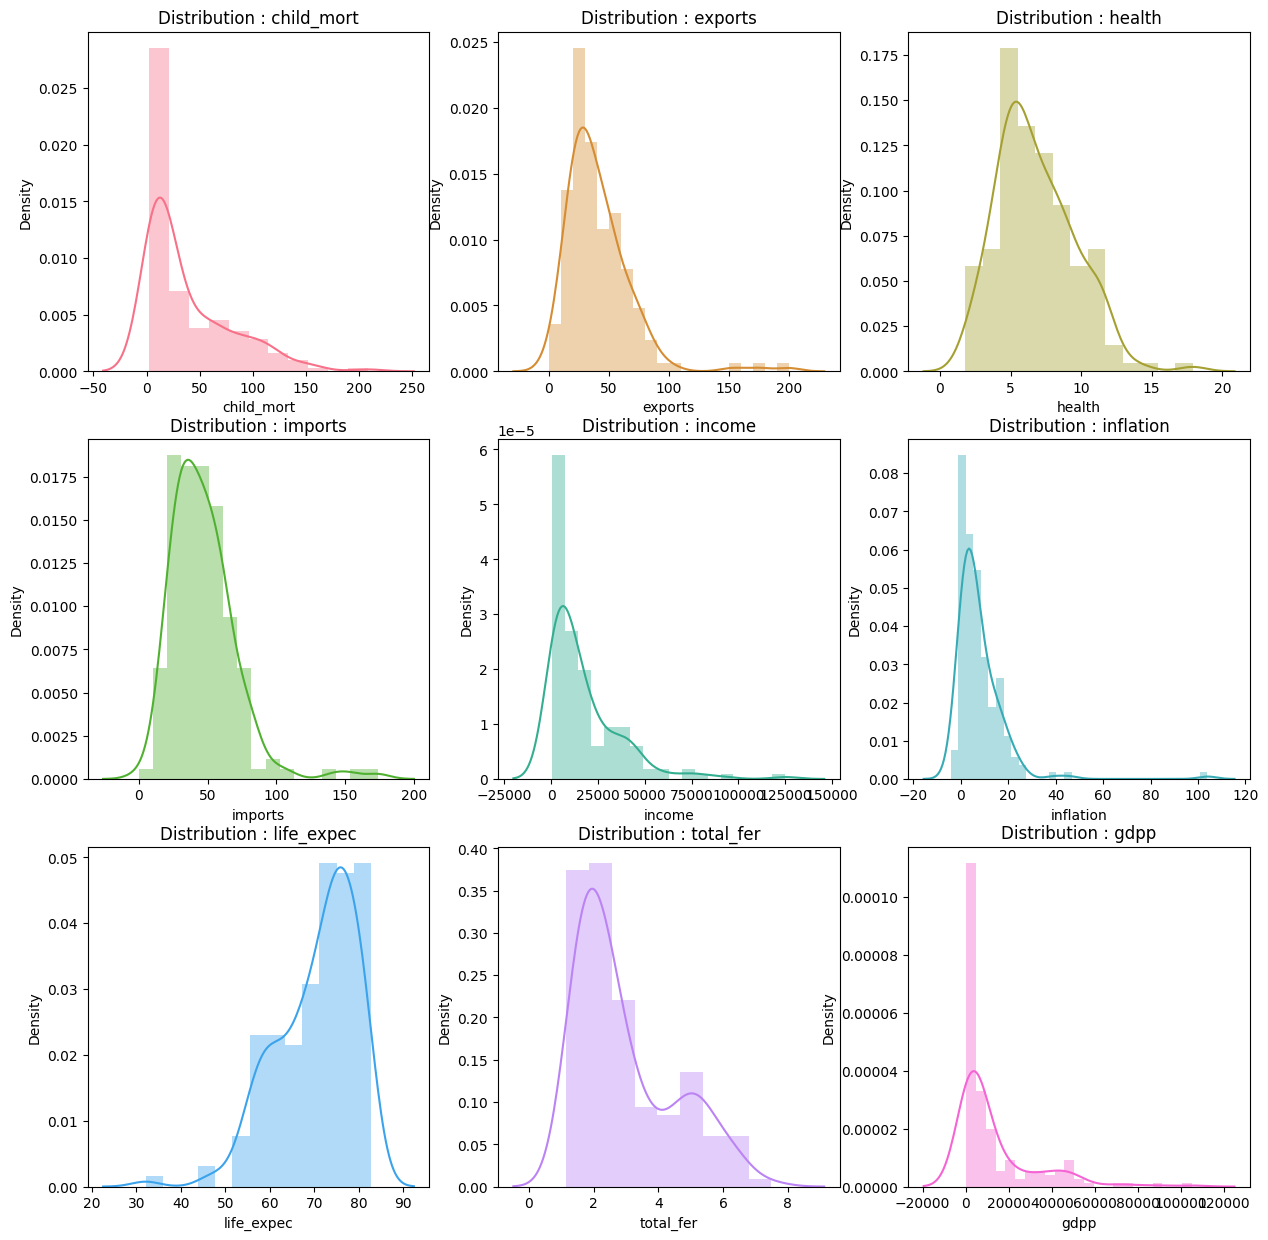

In [17]:
warnings.filterwarnings('ignore')

num_subplots = len(numerical_features)
colors = sns.color_palette("husl", num_subplots)

fig, ax = plt.subplots(nrows = 3,ncols = 3,figsize = (15,15))
for i in range(len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.distplot(df_country[numerical_features[i]], color = colors[i])
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

1. child_mort: Distribusi sangat right-skewed (condong ke kanan), artinya sebagian besar negara memiliki angka kematian anak yang rendah, tapi ada sedikit negara dengan angka tinggi.

2. exports: Juga right-skewed. Mayoritas negara memiliki rasio ekspor yang rendah terhadap PDB, beberapa negara memiliki ekspor sangat tinggi.

3. health: Distribusi agak simetris, meskipun sedikit skewed. Kebanyakan negara memiliki pengeluaran kesehatan rendah hingga sedang.

4. imports: Mirip dengan exports, right-skewed.

5. income: Sangat skewed ke kanan. Mayoritas negara memiliki pendapatan per kapita rendah, beberapa sangat tinggi (kemungkinan negara maju). Perlu transformasi log jika ingin mendekati distribusi normal.

6. inflation: Skewed ke kanan, sebagian besar negara memiliki inflasi rendah dengan beberapa outlier ekstrem.

7. life_expec: Distribusi left-skewed (condong ke kiri). Mayoritas negara memiliki harapan hidup tinggi, tapi beberapa sangat rendah (kemungkinan negara berkembang).

8. total_fer (total fertility rate): Skewed ke kanan. Mayoritas negara memiliki tingkat kesuburan rendah, tetapi ada beberapa dengan tingkat tinggi.

9. gdpp (GDP per capita): Sangat skewed ke kanan, mirip dengan income. Beberapa negara memiliki GDP per kapita jauh lebih tinggi dari mayoritas.

<Axes: >

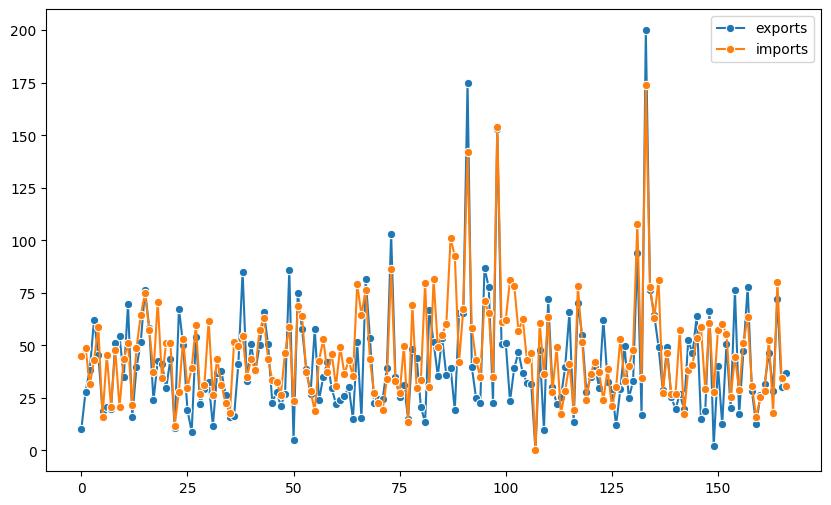

In [18]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_country[['exports', 'imports']], dashes=False, markers='o')

- Baik ekspor maupun impor sangat bervariasi antar negara, ada negara dengan nilai sangat rendah dan ada yang sangat tinggi (terlihat beberapa puncak ekstrim).
- Garis ekspor dan impor sering berdekatan, menunjukkan hubungan yang erat (negara yang banyak mengimpor biasanya juga banyak mengekspor).


## 3.3 Bivariative Analysis

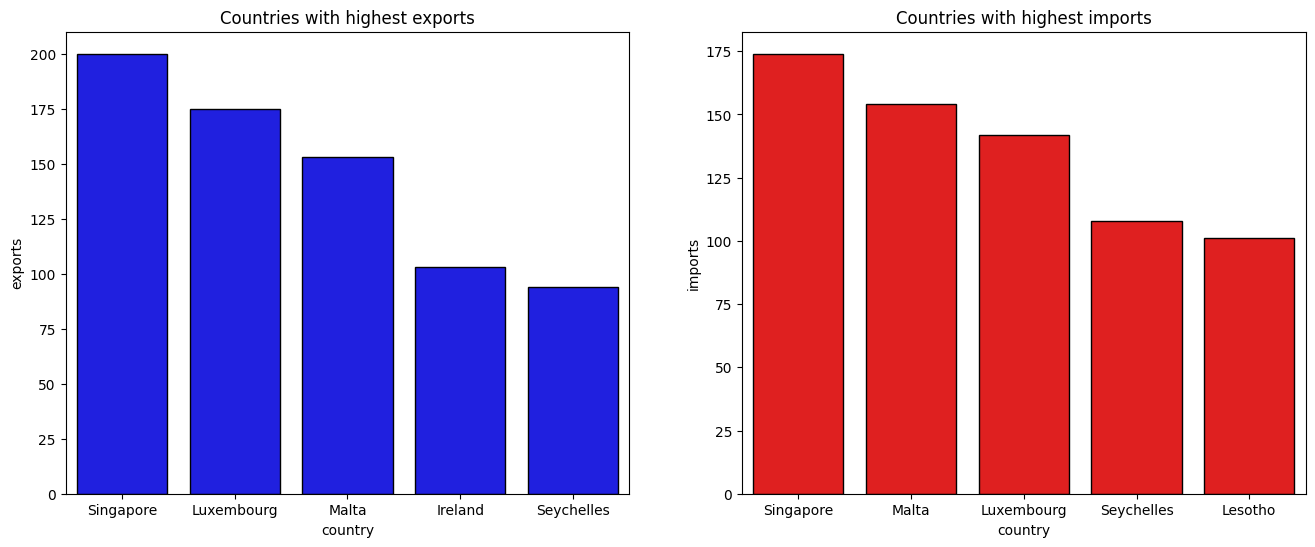

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

axes[0].set_title("Countries with highest exports")
sns.barplot(x='country', y='exports', ax=axes[0], data=df_country.sort_values(ascending = False,by = 'exports').iloc[:5], color = 'blue', edgecolor = 'black')

axes[1].set_title("Countries with highest imports")
sns.barplot(x='country', y='imports', ax=axes[1], data=df_country.sort_values(ascending = False,by = 'imports').iloc[:5], color = 'red', edgecolor = 'black')

plt.show()

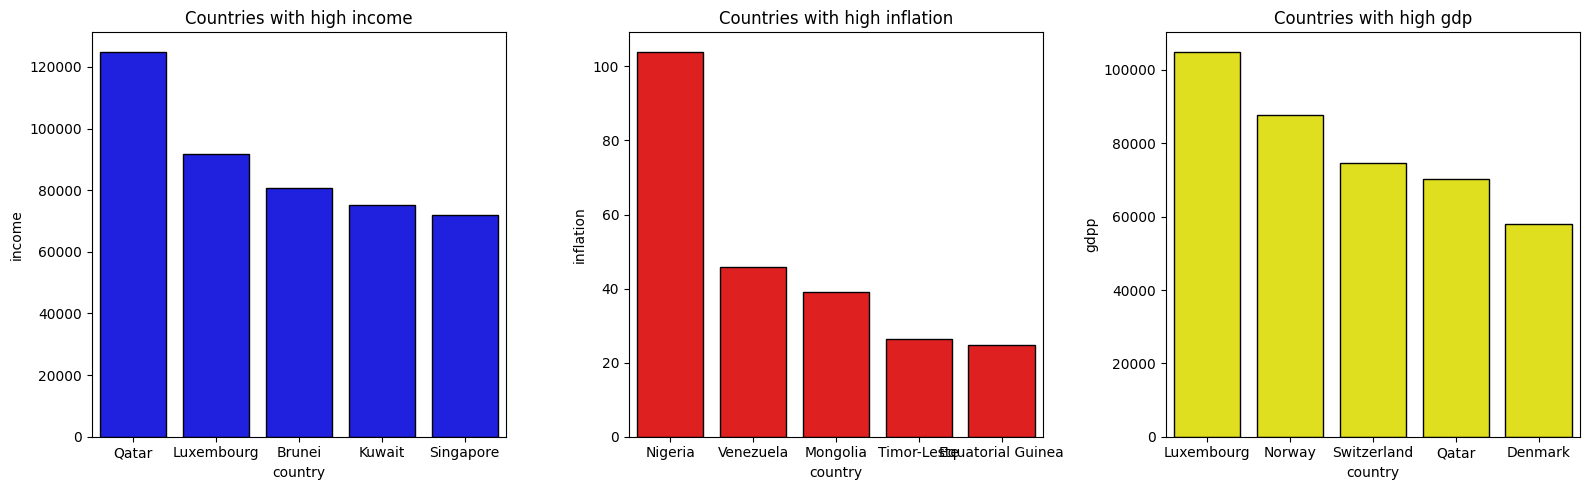

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

axes[0].set_title("Countries with high income")
sns.barplot(x='country', y='income', ax=axes[0], data=df_country.sort_values(ascending = False,by = 'income').iloc[:5], color = 'blue', edgecolor = 'black')

axes[1].set_title("Countries with high inflation")
sns.barplot(x='country', y='inflation', ax=axes[1], data=df_country.sort_values(ascending = False,by = 'inflation').iloc[:5], color = 'red', edgecolor = 'black')

axes[2].set_title("Countries with high gdp")
sns.barplot(x='country', y='gdpp', ax=axes[2], data=df_country.sort_values(ascending = False,by = 'gdpp').iloc[:5], color = 'yellow', edgecolor = 'black')

plt.tight_layout()

plt.show()

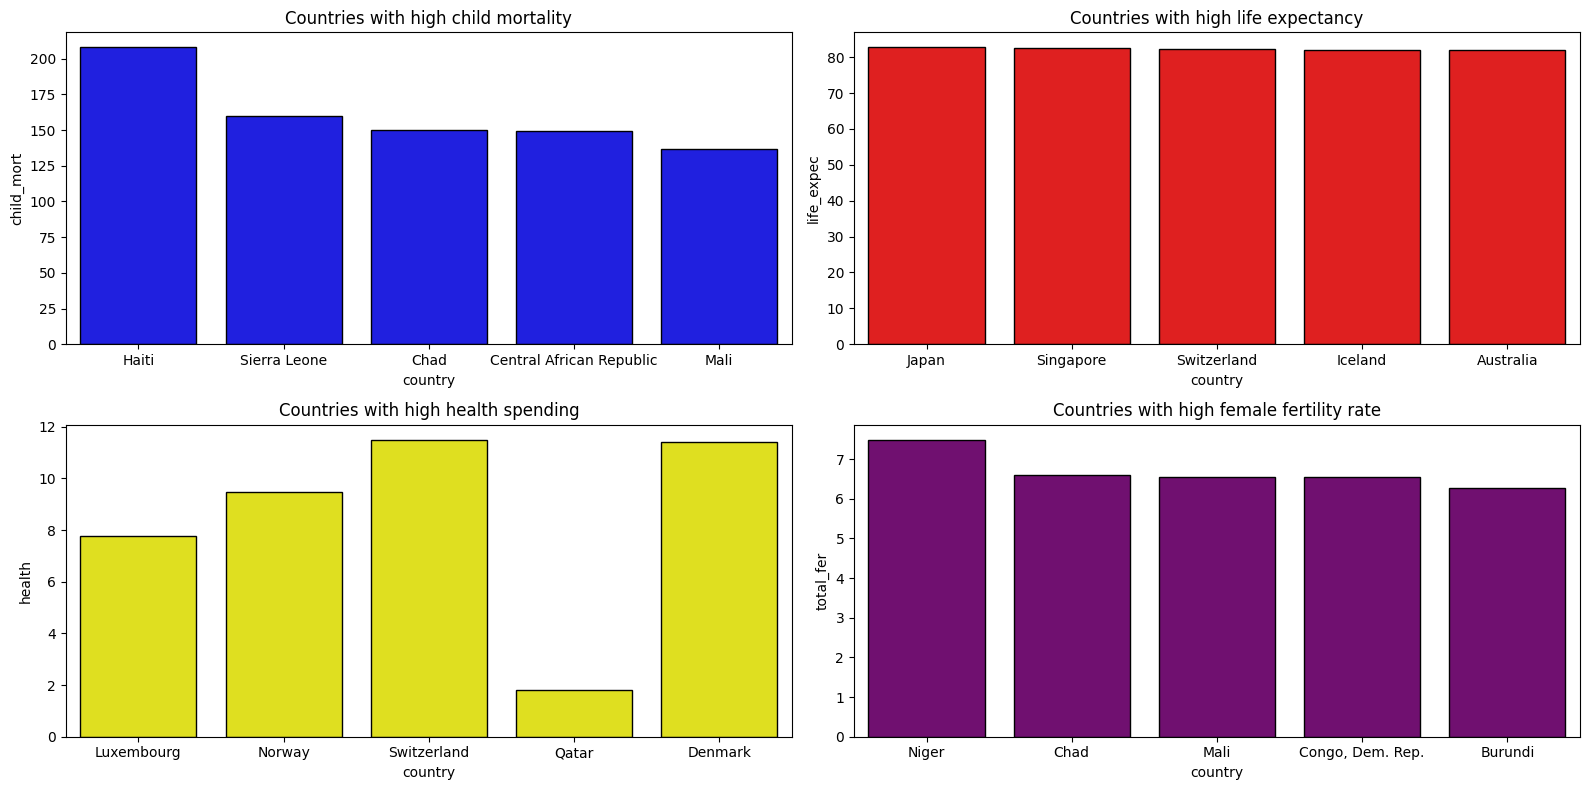

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 8))

axes[0, 0].set_title("Countries with high child mortality")
sns.barplot(x='country', y='child_mort', ax=axes[0, 0], data=df_country.sort_values(ascending = False,by = 'child_mort').iloc[:5], color = 'blue', edgecolor = 'black')

axes[0, 1].set_title("Countries with high life expectancy")
sns.barplot(x='country', y='life_expec', ax=axes[0, 1], data=df_country.sort_values(ascending = False,by = 'life_expec').iloc[:5], color = 'red', edgecolor = 'black')

axes[1, 0].set_title("Countries with high health spending")
sns.barplot(x='country', y='health', ax=axes[1, 0], data=df_country.sort_values(ascending = False,by = 'gdpp').iloc[:5], color = 'yellow', edgecolor = 'black')

axes[1, 1].set_title("Countries with high female fertility rate")
sns.barplot(x='country', y='total_fer', ax=axes[1, 1], data=df_country.sort_values(ascending = False,by = 'total_fer').iloc[:5], color = 'purple', edgecolor = 'black')

plt.tight_layout()

plt.show()

## 4. Clustering model

k hyperparameter: jumlah cluster atau kelompok yang akan digunakan untuk membagi data. Untuk pemilihan nilai k, kita menggunakan 2 uji statistik:

1. Metode Elbow: Ini adalah metode yang memplot jumlah kuadrat kesalahan (sum of squared error) untuk rentang nilai k. Jika plot ini terlihat seperti lengan, maka nilai k yang menyerupai siku dipilih. Dari nilai siku ini, jumlah kuadrat nilai (inertia) mulai menurun secara linear dan dengan demikian dianggap sebagai nilai optimal.

2. Metode Silhouette Score: Ini adalah metode yang mengevaluasi kualitas cluster dalam hal seberapa baik titik data dikelompokkan dengan titik data lain yang serupa satu sama lain. Skor ini dihitung menggunakan rumus jarak dan nilai k dengan skor tertinggi dipilih untuk pemodelan.

In [22]:
# Define the range of clusters to test
k_values = range(2, 11)

# Lists to store metrics
inertia_values = []
silhouette_scores = []

# Iterate over different cluster sizes
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df.iloc[:, 1:])  # Excluding the 'country' column
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df.iloc[:, 1:], kmeans.labels_))

## 4.1 Elbow method

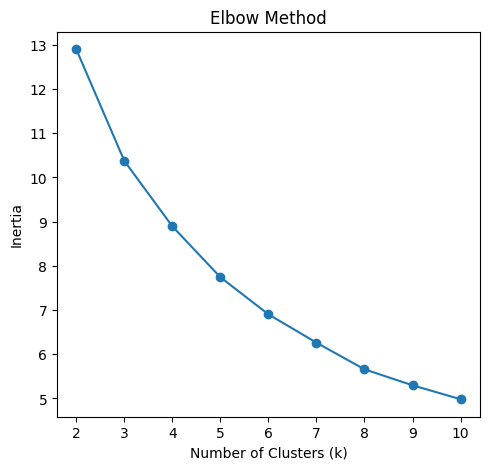

In [23]:
# Plot the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia_values, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## 4.2 Silhouette score method

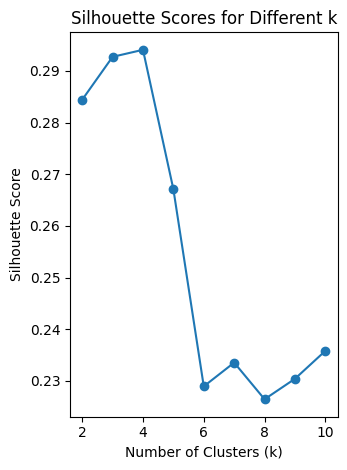

In [24]:
# Plot the Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")

plt.tight_layout()
plt.show()

Berdasarkan hasil dari kedua metode di atas (Elbow Method dan Silhouette Score Method), kita memilih nilai k yang optimal, yaitu jumlah cluster (Clusters) = 3.

## 4.3 K-means model

In [25]:
kmeans = KMeans(n_clusters=3).fit(df)
df.insert(0, 'Country', df_country['country'])
df['class'] = kmeans.labels_
df['Label'] = df['class']

In [26]:
#count number of records in every cluster
pd.Series(kmeans.labels_).value_counts()

,count
2,87
1,46
0,34


In [27]:
poor = int(df[df.Country=='Afghanistan']['class'])
midle = int(df[df.Country=='Iran']['class'])
rich = int(df[df.Country=='Canada']['class'])

In [28]:
poor_label = 'Poor countries'
midle_label = 'Midle countries'
rich_label = 'Rich countries'

In [29]:
df.replace({'Label':{poor:'Poor countries', midle:'Midle countries', rich:'Rich countries'}},inplace=True)
df.head()

,Country,PC1,PC2,PC3,PC4,PC5,class,Label
0,Afghanistan,0.599065,0.095506,0.157437,0.024382,0.042560,1,Poor countries
1,Albania,-0.158455,-0.212345,-0.063709,0.061067,-0.017134,2,Midle countries
2,Algeria,-0.003661,-0.135842,-0.133938,-0.133376,0.092225,2,Midle countries
3,Angola,0.650272,0.276016,-0.143024,-0.155593,0.083921,1,Poor countries
4,Antigua and Barbuda,-0.200684,-0.065162,-0.100418,0.037680,0.030574,2,Midle countries


In [30]:
fig = px.choropleth(df[['Country','class']],
                    locationmode = 'country names',
                    locations = 'Country',
                    color = df['Label'],
                    color_discrete_map = {'Rich countries': 'Green',
                                          'Midle countries':'LightBlue',
                                          'Poor countries':'Red'}
                   )

fig.update_layout(
        margin = dict(
                l=0,
                r=0,
                b=0,
                t=0,
                pad=2,
            ),
    )
fig.show()

In [31]:
labels = kmeans.labels_
cluster_df = pd.DataFrame({'Country': df_country['country'], 'Cluster': labels})
cluster_members = cluster_df.groupby('Cluster')['Country'].apply(list).to_dict()
for cluster, members in cluster_members.items():
    print(f"Cluster {cluster}: {members}")

Cluster 0: ['Australia', 'Austria', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']
Cluster 1: ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']
Clust